# ***LAB PROJECT***


PROJECT MIDTERM: COMPARATIVE ANALYSIS TABLE


,Algorithm,Discovered Path,Total Cost,Nodes Expanded,Execution Time (ms)
0,BFS,Start_Node -> Web_Server -> Internal_Router ->...,14,8,0.030279
1,DFS,Start_Node -> Web_Server -> Internal_Router ->...,12,7,0.019550
2,UCS,Start_Node -> Firewall -> Internal_Router -> D...,11,8,0.021696
3,A*,Start_Node -> Web_Server -> Internal_Router ->...,12,8,0.019789
4,Hill Climbing,TRAPPED at Honeypot (Local Max),3,3,0.013351
5,Alpha-Beta,Start_Node -> Web_Server -> Internal_Router ->...,12,13,0.040531


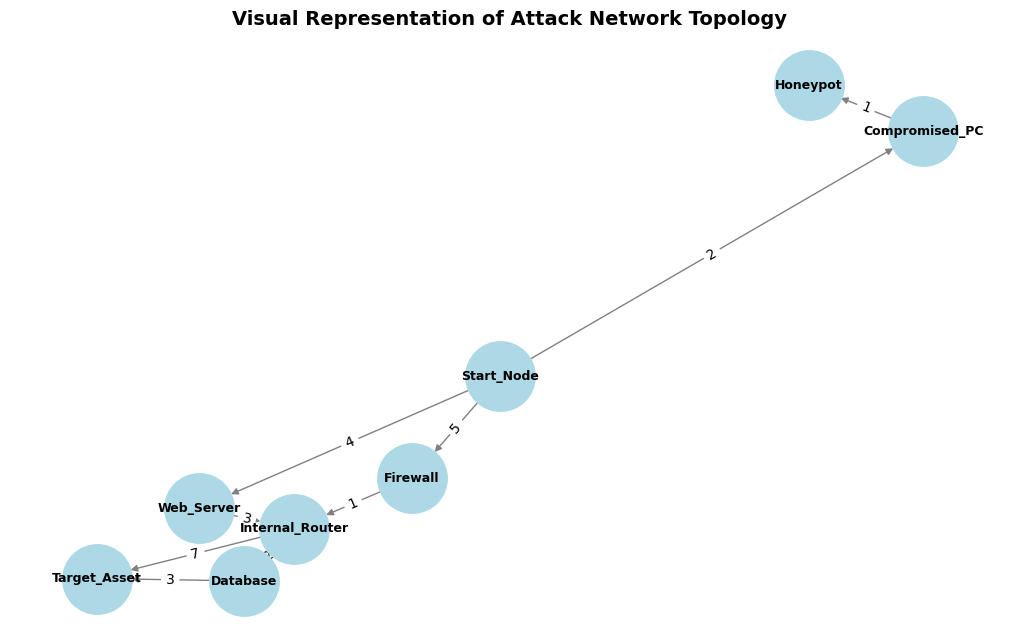

In [1]:
import time
import heapq
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. NETWORK TOPOLOGY & HEURISTICS
# ==========================================
# 8 Nodes. We intentionally design a "Honeypot" to trap Hill Climbing.
network_graph = {
    'Start_Node': [('Compromised_PC', 2), ('Web_Server', 4), ('Firewall', 5)],
    'Compromised_PC': [('Honeypot', 1)], # Trap! Looks good but dead end.
    'Honeypot': [], # Local Maximum trap
    'Web_Server': [('Internal_Router', 3)],
    'Firewall': [('Internal_Router', 1)],
    'Internal_Router': [('Database', 2), ('Target_Asset', 7)],
    'Database': [('Target_Asset', 3)],
    'Target_Asset': []
}

# Heuristics (Estimated cost to Target_Asset)
# Honeypot has a low heuristic (2) to lure Hill Climbing away from the real path.
heuristics = {
    'Start_Node': 10,
    'Compromised_PC': 5,
    'Honeypot': 2,
    'Web_Server': 6,
    'Firewall': 7,
    'Internal_Router': 4,
    'Database': 2,
    'Target_Asset': 0
}

# Helper Function: Calculate total path cost
def get_path_cost(path):
    cost = 0
    for i in range(len(path) - 1):
        for neighbor, weight in network_graph[path[i]]:
            if neighbor == path[i+1]:
                cost += weight
                break
    return cost

# ==========================================
# 2. UNINFORMED SEARCH ALGORITHMS
# ==========================================
def run_bfs(start, goal):
    start_time = time.time()
    queue = [[start]]
    visited = set()
    expanded = 0

    while queue:
        path = queue.pop(0)
        node = path[-1]

        if node not in visited:
            expanded += 1
            if node == goal:
                return " -> ".join(path), get_path_cost(path), expanded, (time.time() - start_time) * 1000

            visited.add(node)
            for neighbor, _ in network_graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return "No Path", 0, expanded, (time.time() - start_time) * 1000

def run_dfs(start, goal):
    start_time = time.time()
    stack = [[start]] # Using stack for DFS
    visited = set()
    expanded = 0

    while stack:
        path = stack.pop(-1)
        node = path[-1]

        if node not in visited:
            expanded += 1
            if node == goal:
                return " -> ".join(path), get_path_cost(path), expanded, (time.time() - start_time) * 1000

            visited.add(node)
            # Reverse to maintain standard left-to-right exploration
            for neighbor, _ in reversed(network_graph[node]):
                new_path = list(path)
                new_path.append(neighbor)
                stack.append(new_path)

    return "No Path", 0, expanded, (time.time() - start_time) * 1000

# ==========================================
# 3. INFORMED SEARCH ALGORITHMS
# ==========================================
def run_ucs(start, goal):
    start_time = time.time()
    pq = [(0, [start])] # Priority Queue: (cost, path)
    visited = set()
    expanded = 0

    while pq:
        cost, path = heapq.heappop(pq)
        node = path[-1]

        if node not in visited:
            expanded += 1
            if node == goal:
                return " -> ".join(path), cost, expanded, (time.time() - start_time) * 1000

            visited.add(node)
            for neighbor, weight in network_graph[node]:
                if neighbor not in visited:
                    heapq.heappush(pq, (cost + weight, path + [neighbor]))

    return "No Path", 0, expanded, (time.time() - start_time) * 1000

def run_astar(start, goal):
    start_time = time.time()
    # Priority Queue: (f_score, g_cost, path)
    pq = [(heuristics[start], 0, [start])]
    visited = set()
    expanded = 0

    while pq:
        f_score, g_cost, path = heapq.heappop(pq)
        node = path[-1]

        if node not in visited:
            expanded += 1
            if node == goal:
                return " -> ".join(path), g_cost, expanded, (time.time() - start_time) * 1000

            visited.add(node)
            for neighbor, weight in network_graph[node]:
                if neighbor not in visited:
                    new_g = g_cost + weight
                    new_f = new_g + heuristics[neighbor]
                    heapq.heappush(pq, (new_f, new_g, path + [neighbor]))

    return "No Path", 0, expanded, (time.time() - start_time) * 1000

# ==========================================
# 4. LOCAL SEARCH (HILL CLIMBING)
# ==========================================
def run_hill_climbing(start, goal):
    start_time = time.time()
    current = start
    path = [start]
    expanded = 0

    while current != goal:
        expanded += 1
        neighbors = network_graph[current]
        if not neighbors:
            break # Dead end

        # Find neighbor with lowest heuristic
        best_neighbor = None
        best_h = float('inf')
        for neighbor, _ in neighbors:
            if heuristics[neighbor] < best_h:
                best_h = heuristics[neighbor]
                best_neighbor = neighbor

        # If the best neighbor is worse or equal to current, we are stuck (Local Maxima)
        if best_h >= heuristics[current]:
            break

        current = best_neighbor
        path.append(current)

    cost = get_path_cost(path)
    if current == goal:
        return " -> ".join(path), cost, expanded, (time.time() - start_time) * 1000
    else:
        return f"TRAPPED at {current} (Local Max)", cost, expanded, (time.time() - start_time) * 1000

# ==========================================
# 5. ADVERSARIAL SEARCH (MINIMAX + ALPHA-BETA)
# ==========================================
def alpha_beta_search(node, depth, is_attacker, alpha, beta, expanded_counter):
    expanded_counter[0] += 1
    if depth == 0 or not network_graph[node] or node == 'Target_Asset':
        return heuristics[node], [node] # Base case: return heuristic score

    best_path = []
    if is_attacker: # Maximizer (wants to minimize heuristic distance, so we maximize negative heuristic)
        max_eval = float('-inf')
        for neighbor, _ in network_graph[node]:
            eval_score, path = alpha_beta_search(neighbor, depth - 1, False, alpha, beta, expanded_counter)
            eval_score = -eval_score # Negate to maximize
            if eval_score > max_eval:
                max_eval = eval_score
                best_path = [node] + path
            alpha = max(alpha, eval_score)
            if beta <= alpha:
                break # Alpha-Beta Pruning
        return -max_eval, best_path
    else: # Defender (Minimizer - simulates worst case for attacker)
        min_eval = float('inf')
        for neighbor, _ in network_graph[node]:
            eval_score, path = alpha_beta_search(neighbor, depth - 1, True, alpha, beta, expanded_counter)
            eval_score = -eval_score
            if eval_score < min_eval:
                min_eval = eval_score
                best_path = [node] + path
            beta = min(beta, eval_score)
            if beta <= alpha:
                break # Alpha-Beta Pruning
        return -min_eval, best_path

def run_adversarial_agent(start, goal):
    start_time = time.time()
    expanded_counter = [0]
    # Simulate attacker planning 4 steps ahead
    score, path = alpha_beta_search(start, 4, True, float('-inf'), float('inf'), expanded_counter)

    # Clean up path if it reached goal early
    final_path = []
    for p in path:
        final_path.append(p)
        if p == goal: break

    exec_time = (time.time() - start_time) * 1000
    return " -> ".join(final_path), get_path_cost(final_path), expanded_counter[0], exec_time


# ==========================================
# 6. EXECUTION & OUTPUT (GUI & Table)
# ==========================================
start_node = 'Start_Node'
goal_node = 'Target_Asset'

results = []
results.append(("BFS", *run_bfs(start_node, goal_node)))
results.append(("DFS", *run_dfs(start_node, goal_node)))
results.append(("UCS", *run_ucs(start_node, goal_node)))
results.append(("A*", *run_astar(start_node, goal_node)))
results.append(("Hill Climbing", *run_hill_climbing(start_node, goal_node)))
results.append(("Alpha-Beta", *run_adversarial_agent(start_node, goal_node)))

# Print Comparative Analysis Table
df = pd.DataFrame(results, columns=["Algorithm", "Discovered Path", "Total Cost", "Nodes Expanded", "Execution Time (ms)"])
print("\n" + "="*80)
print("PROJECT MIDTERM: COMPARATIVE ANALYSIS TABLE")
print("="*80)
display(df) # Renders a nice table in Colab

# Visual UI Representation (NetworkX)
plt.figure(figsize=(10, 6))
G = nx.DiGraph()
for node, edges in network_graph.items():
    for neighbor, weight in edges:
        G.add_edge(node, neighbor, weight=weight)

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, font_size=9, font_weight='bold', edge_color='gray')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Visual Representation of Attack Network Topology", fontsize=14, fontweight='bold')
plt.show()

OVERLEAF REPORT LINK:https://www.overleaf.com/project/6a15b75a7b4e41206483135a